# StormEngine — Seasonal Analysis of Mean Sea Level Pressure (MSL)

Seasonal analysis of MSL across four monthly files spanning two seasons:

| File | Month | Season |
|---|---|---|
| `final_2024_1_msl.csv`  | January  | Winter |
| `final_2024_2_msl.csv`  | February | Winter |
| `final_2024_11_msl.csv` | November | Autumn |
| `final_2024_12_msl.csv` | December | Winter |

## File structure
Each file is a spatial grid of **1023 points** (31 lat × 33 lon) over the domain `[39–46.5°N, 12–20°E]`:
- `VALUE` — ERA5 reference value at each grid point (Pa)
- `SAMPLE_1 … SAMPLE_744` — one hourly realisation per hour of the month (31 days × 24 h)
- `lon`, `lat` — grid point coordinates

All pressure values are converted from **Pa → hPa** (÷100).

## 0. Imports and Configuration

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# ── Professional plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 110,
    'savefig.dpi'       : 200,
    'font.size'         : 11,
    'font.family'       : 'sans-serif',
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linewidth'    : 0.7,
    'legend.frameon'    : False,
})

# ── Files and metadata ──────────────────────────────────────────────────────
FILES = {
    'November' : {'path': 'final_2024_11_msl.csv', 'month': 11, 'season': 'Autumn', 'days': 30},
    'December' : {'path': 'final_2024_12_msl.csv', 'month': 12, 'season': 'Winter', 'days': 31},
    'January'  : {'path': 'final_2024_1_msl.csv',  'month': 1,  'season': 'Winter', 'days': 31},
    'February' : {'path': 'final_2024_2_msl.csv',  'month': 2,  'season': 'Winter', 'days': 29},
}

# Consistent colour per month
MONTH_COLORS = {
    'January'  : '#2c7fb8',
    'February' : '#41b6c4',
    'November' : '#fb8d3d',
    'December' : '#08519c',
}

PA_TO_HPA = 1.0 / 100.0
VARIABLE  = 'MSL'
UNIT      = 'hPa'

# Domain
LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0

## 1. Load Data and Convert Units

For each month we load the grid, identify the `SAMPLE_*` columns, drop hourly columns that are entirely empty (months shorter than 31 days), and convert Pa → hPa.

In [17]:
def load_month(path):
    """Load one monthly MSL grid file, convert Pa->hPa, return components."""
    df = pd.read_csv(path)

    sample_cols = [c for c in df.columns if c.startswith('SAMPLE_')]

    # Spatial reference value (ERA5) and coordinates
    value = df['VALUE'].values * PA_TO_HPA          # (n_points,)
    lon   = df['lon'].values
    lat   = df['lat'].values

    # Hourly samples matrix: (n_points, n_hours)
    samples = df[sample_cols].values * PA_TO_HPA

    # Drop fully-NaN hourly columns (e.g. day 30/31 in shorter months)
    valid_hours = ~np.all(np.isnan(samples), axis=0)
    samples = samples[:, valid_hours]

    return {
        'value'   : value,        # (n_points,)
        'samples' : samples,      # (n_points, n_hours)
        'lon'     : lon,
        'lat'     : lat,
        'n_points': len(value),
        'n_hours' : samples.shape[1],
    }


data = {}
for month, meta in FILES.items():
    try:
        d = load_month(meta['path'])
        d.update(meta)
        data[month] = d
        print(f'{month:9s} | season={meta["season"]:7s} | '
              f'points={d["n_points"]} | hours={d["n_hours"]} | '
              f'domain mean={np.nanmean(d["samples"]):.2f} {UNIT}')
    except FileNotFoundError:
        print(f'{month:9s} | FILE NOT FOUND: {meta["path"]}')

November  | season=Autumn  | points=1024 | hours=720 | domain mean=1021.68 hPa
December  | season=Winter  | points=1023 | hours=744 | domain mean=1020.47 hPa
January   | season=Winter  | points=1023 | hours=744 | domain mean=1019.27 hPa
February  | season=Winter  | points=1023 | hours=744 | domain mean=1019.27 hPa


## 2. Summary Statistics per Month

Domain-averaged statistics: each hourly sample is first averaged over all grid points, giving one time series per month, then summarised.

In [18]:
rows = []
for month, d in data.items():
    # Domain-mean time series: average over grid points -> (n_hours,)
    ts = np.nanmean(d['samples'], axis=0)
    rows.append({
        'Month'  : month,
        'Season' : d['season'],
        'Mean'   : np.mean(ts),
        'Std'    : np.std(ts),
        'Min'    : np.min(ts),
        'Max'    : np.max(ts),
        'Range'  : np.max(ts) - np.min(ts),
        'Median' : np.median(ts),
    })

summary = pd.DataFrame(rows).set_index('Month').round(2)
print(f'Domain-averaged {VARIABLE} statistics ({UNIT})\n')
print(summary.to_string())

Domain-averaged MSL statistics (hPa)

          Season     Mean    Std     Min      Max  Range   Median
Month                                                            
November  Autumn  1021.68   7.47  997.38  1034.85  37.46  1023.24
December  Winter  1020.47   8.71  997.57  1034.19  36.62  1020.97
January   Winter  1019.27  10.95  995.47  1037.10  41.63  1020.53
February  Winter  1019.27  10.95  995.47  1037.10  41.63  1020.53


## 3. Monthly Time Series — Domain-Averaged MSL

Hourly evolution of the domain-mean pressure for each month, revealing the passage of synoptic systems (high/low pressure cycles).

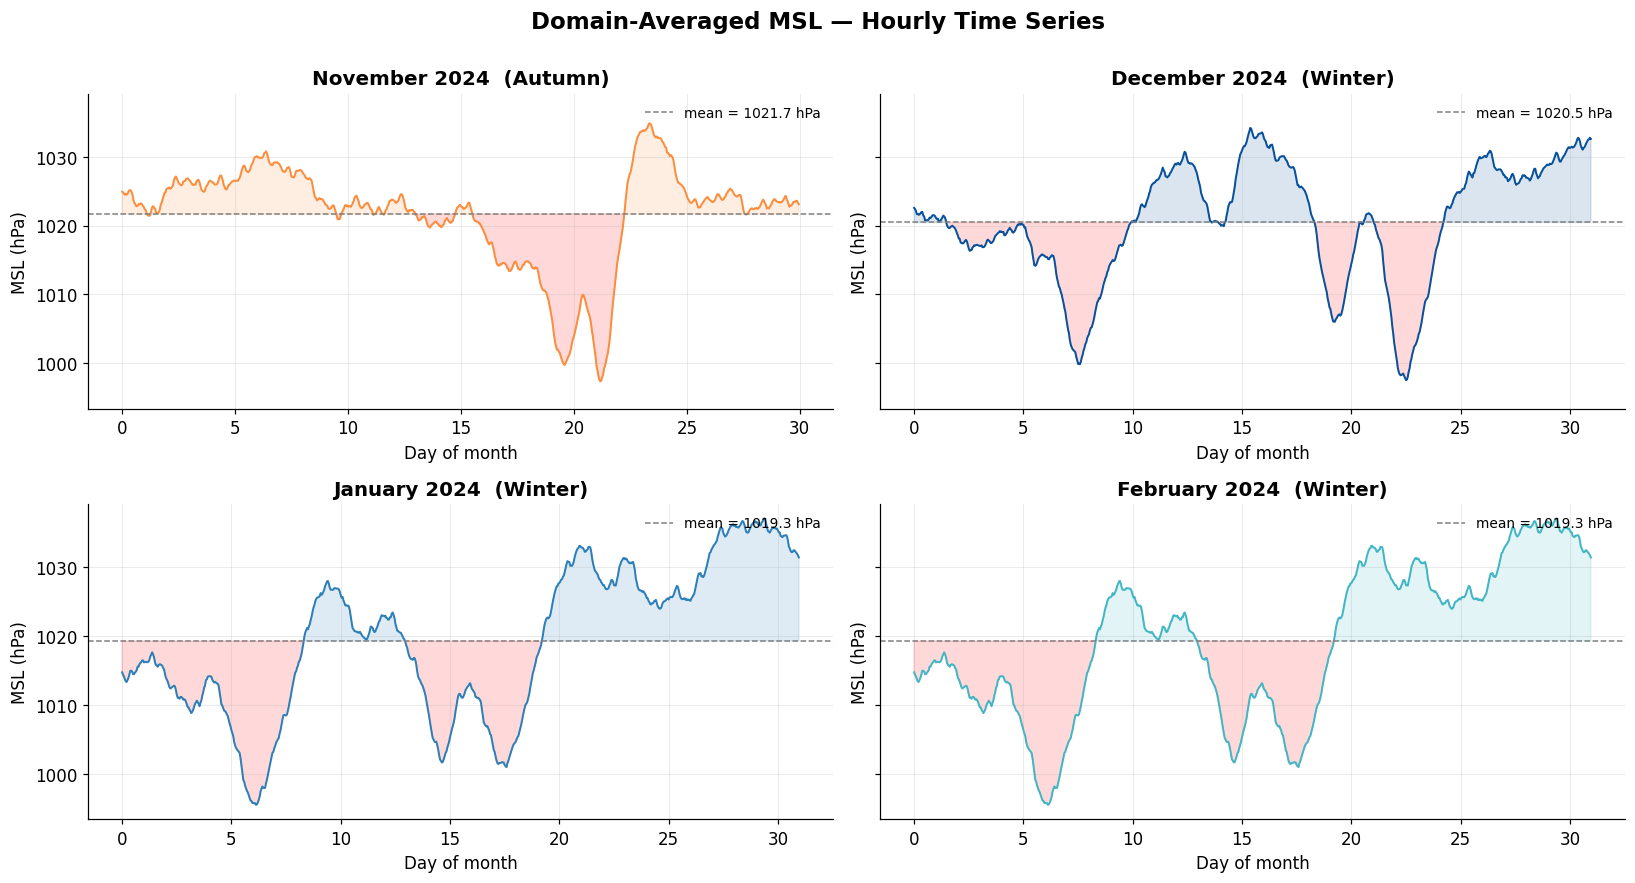

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, (month, d) in zip(axes, data.items()):
    ts   = np.nanmean(d['samples'], axis=0)
    hours = np.arange(len(ts))
    days  = hours / 24.0

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.3)
    ax.axhline(ts.mean(), color='gray', linestyle='--', linewidth=1,
               label=f'mean = {ts.mean():.1f} {UNIT}')
    ax.fill_between(days, ts, ts.mean(),
                    where=(ts >= ts.mean()), alpha=0.15,
                    color=MONTH_COLORS[month])
    ax.fill_between(days, ts, ts.mean(),
                    where=(ts < ts.mean()), alpha=0.15, color='red')

    ax.set_title(f'{month} 2024  ({d["season"]})')
    ax.set_xlabel('Day of month')
    ax.set_ylabel(f'{VARIABLE} ({UNIT})')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle(f'Domain-Averaged {VARIABLE} — Hourly Time Series',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('msl_monthly_timeseries.png', bbox_inches='tight')
plt.show()

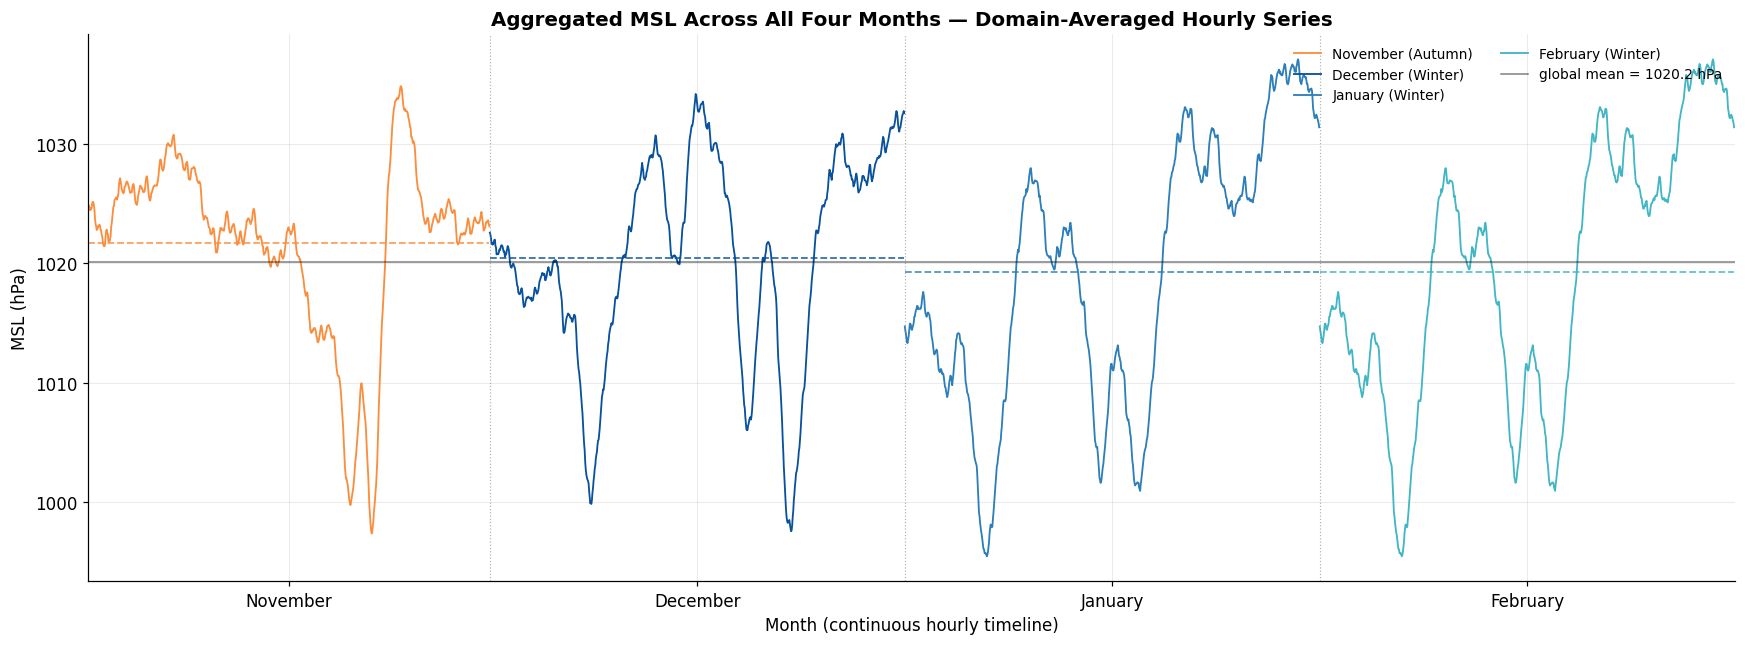

In [20]:
# ── Aggregated continuous time series across all four months ────────────────
fig, ax = plt.subplots(figsize=(16, 6))

cursor = 0          # posizione corrente sull'asse x (in giorni cumulativi)
boundaries = []     # confini tra i mesi per le linee divisorie
tick_pos = []       # posizione centrale di ogni mese per le etichette
tick_lab = []

for month, d in data.items():
    ts = np.nanmean(d['samples'], axis=0)        # serie domain-mean (n_hours,)
    days = cursor + np.arange(len(ts)) / 24.0     # asse in giorni cumulativi

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.2,
            label=f'{month} ({d["season"]})')

    # media mensile come segmento orizzontale tratteggiato
    ax.hlines(ts.mean(), days[0], days[-1],
              color=MONTH_COLORS[month], linestyle='--', linewidth=1.2, alpha=0.8)

    tick_pos.append(cursor + len(ts)/24.0 / 2)
    tick_lab.append(month)
    cursor += len(ts) / 24.0
    boundaries.append(cursor)

# linee verticali di separazione tra i mesi
for b in boundaries[:-1]:
    ax.axvline(b, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

# media globale su tutti i mesi
global_mean = np.concatenate([np.nanmean(d['samples'], axis=0) for d in data.values()]).mean()
ax.axhline(global_mean, color='black', linewidth=1, alpha=0.5,
           label=f'global mean = {global_mean:.1f} {UNIT}')

# etichette dei mesi sotto l'asse
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab)
ax.set_xlim(0, cursor)
ax.set_ylabel(f'{VARIABLE} ({UNIT})')
ax.set_xlabel('Month (continuous hourly timeline)')
ax.set_title(f'Aggregated {VARIABLE} Across All Four Months — Domain-Averaged Hourly Series')
ax.legend(loc='upper right', ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('msl_aggregated_timeline.png', bbox_inches='tight')
plt.show()

## 4. Distribution Comparison — Violin + Box Plots

Distribution of all hourly domain-mean values per month. Wider/taller shapes indicate more variable pressure regimes (typical of active autumn/winter synoptic activity).

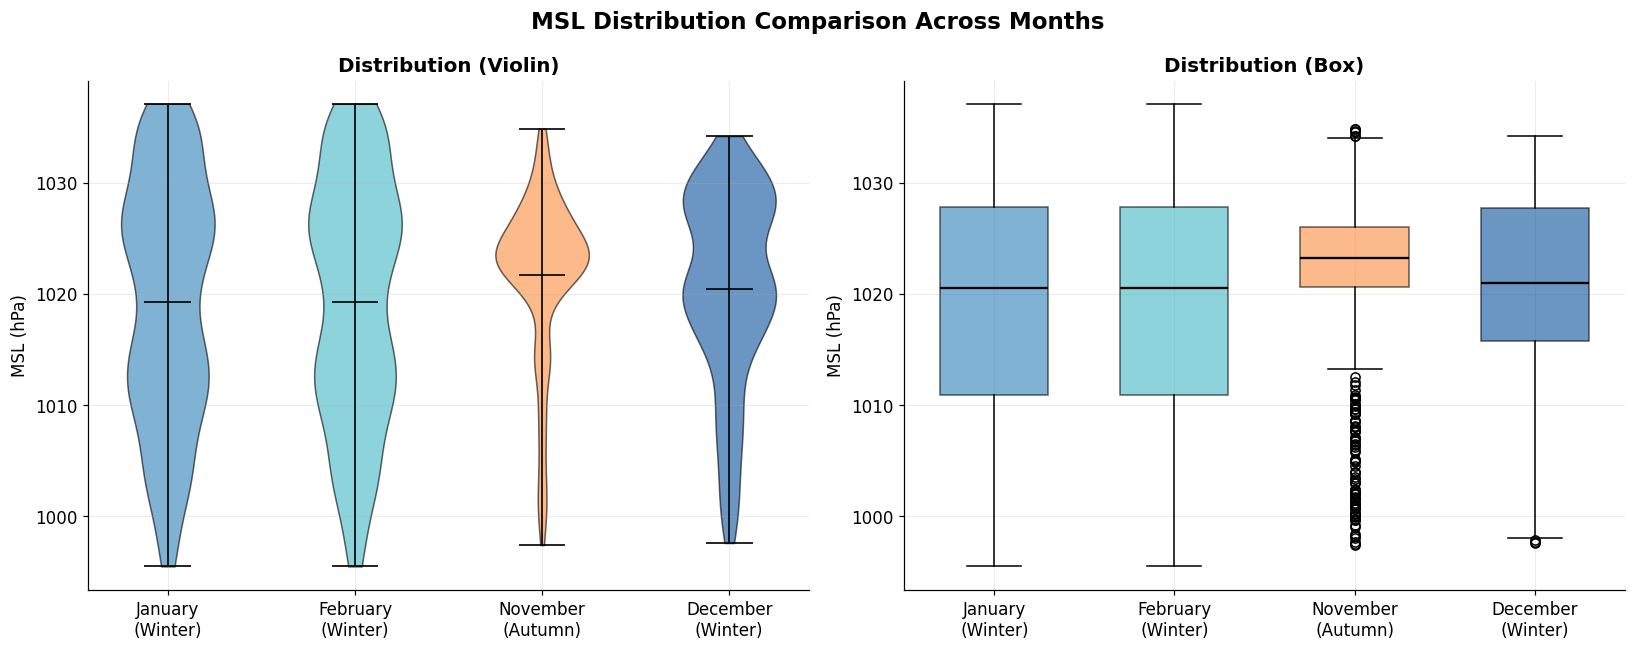

In [5]:
months   = list(data.keys())
ts_all   = [np.nanmean(data[m]['samples'], axis=0) for m in months]
colors   = [MONTH_COLORS[m] for m in months]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Violin plot ─────────────────────────────────────────────────────────────
parts = ax1.violinplot(ts_all, showmeans=True, showmedians=False)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.6); pc.set_edgecolor('black')
for key in ['cmeans', 'cmaxes', 'cmins', 'cbars']:
    if key in parts:
        parts[key].set_edgecolor('black'); parts[key].set_linewidth(1.1)
ax1.set_xticks(range(1, len(months)+1))
ax1.set_xticklabels([f'{m}\n({data[m]["season"]})' for m in months])
ax1.set_ylabel(f'{VARIABLE} ({UNIT})')
ax1.set_title('Distribution (Violin)')

# ── Box plot ────────────────────────────────────────────────────────────────
bp = ax2.boxplot(ts_all, patch_artist=True, widths=0.6,
                 medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax2.set_xticks(range(1, len(months)+1))
ax2.set_xticklabels([f'{m}\n({data[m]["season"]})' for m in months])
ax2.set_ylabel(f'{VARIABLE} ({UNIT})')
ax2.set_title('Distribution (Box)')

fig.suptitle(f'{VARIABLE} Distribution Comparison Across Months',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('msl_distributions.png', bbox_inches='tight')
plt.show()

## 5. Diurnal Cycle — Average MSL by Hour of Day

The semidiurnal atmospheric tide produces a characteristic twice-daily oscillation in surface pressure. Averaging over all days isolates this signal from synoptic noise.

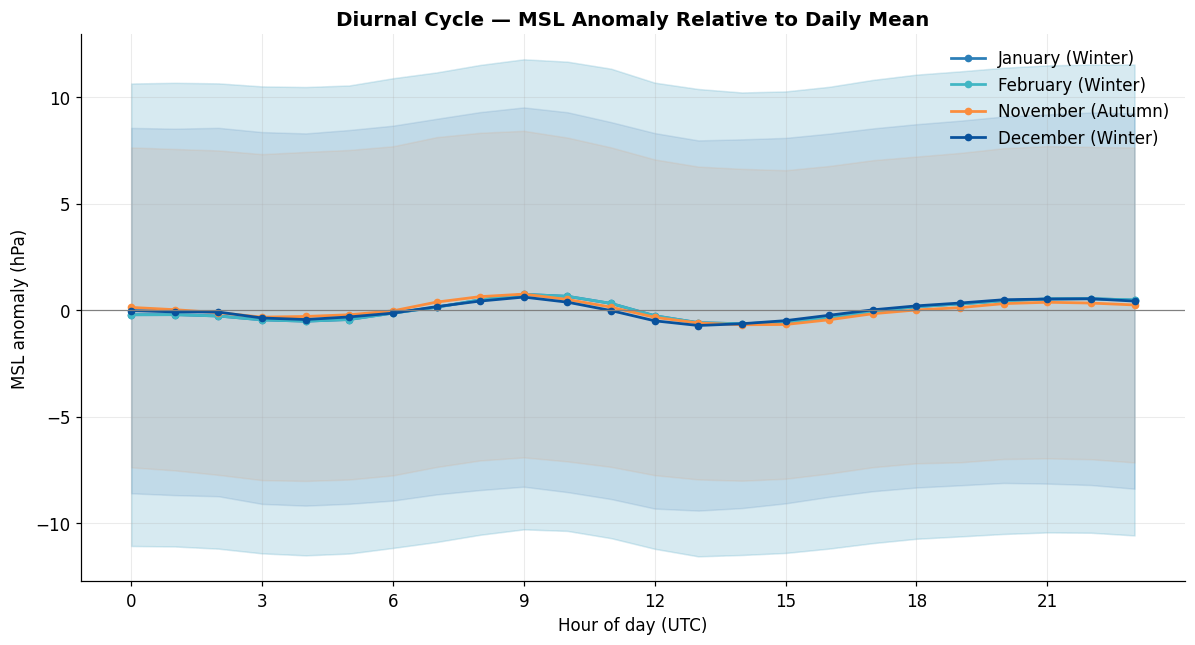

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

for month, d in data.items():
    ts = np.nanmean(d['samples'], axis=0)        # (n_hours,)
    n_full_days = len(ts) // 24
    ts_days = ts[:n_full_days * 24].reshape(n_full_days, 24)

    diurnal_mean = ts_days.mean(axis=0)
    diurnal_std  = ts_days.std(axis=0)

    # Anomaly relative to daily mean (isolates the cycle shape)
    anomaly = diurnal_mean - diurnal_mean.mean()
    anom_std = diurnal_std

    hours = np.arange(24)
    ax.plot(hours, anomaly, marker='o', markersize=4,
            color=MONTH_COLORS[month], linewidth=1.8,
            label=f'{month} ({d["season"]})')
    ax.fill_between(hours, anomaly - anom_std, anomaly + anom_std,
                    color=MONTH_COLORS[month], alpha=0.10)

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel(f'{VARIABLE} anomaly ({UNIT})')
ax.set_title('Diurnal Cycle — MSL Anomaly Relative to Daily Mean')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('msl_diurnal_cycle.png', bbox_inches='tight')
plt.show()

## 6. Spatial Maps — Monthly Mean MSL Field

The time-averaged pressure field reconstructed on the 31×33 spatial grid, one map per month. Reveals the persistent spatial pressure gradient across the domain (e.g. north-south or land-sea contrasts).

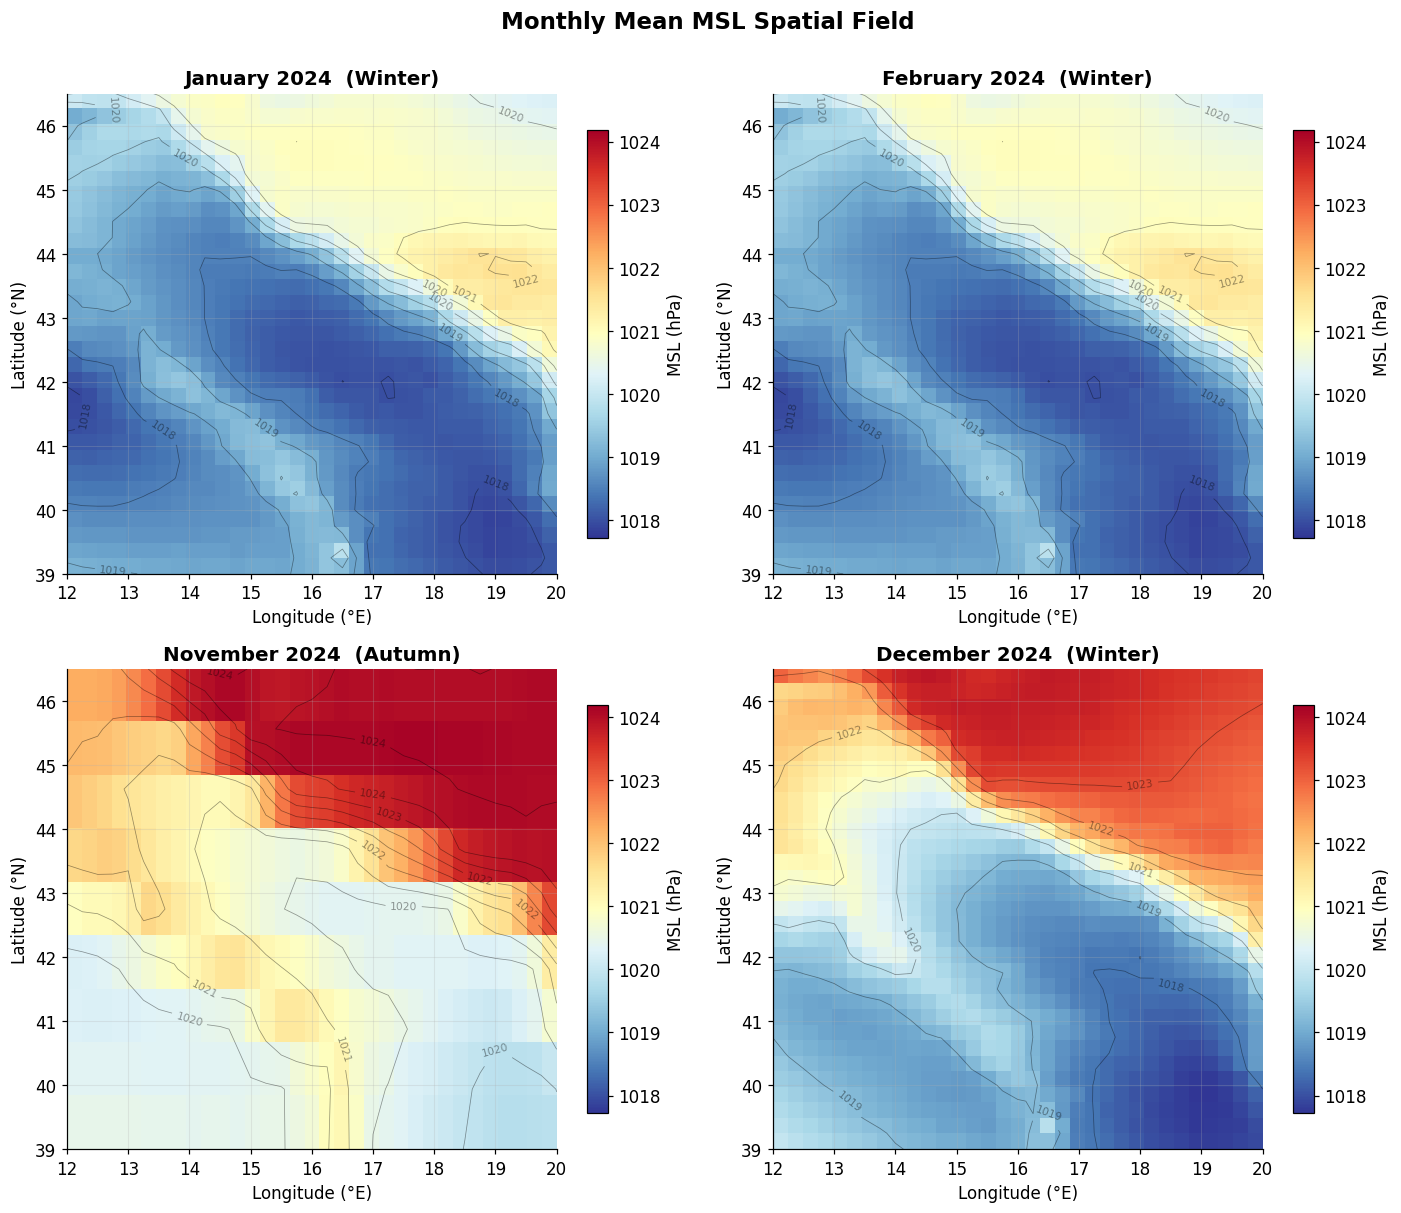

In [12]:
def to_grid(values, lon, lat):
    """Reshape a flat per-point vector into a (n_lat, n_lon) grid.
    Skips points with NaN coordinates."""
    # Tieni solo punti con lon E lat validi
    valid = ~(np.isnan(lon) | np.isnan(lat))
    values, lon, lat = values[valid], lon[valid], lat[valid]

    lons = np.sort(np.unique(lon))
    lats = np.sort(np.unique(lat))[::-1]   # north at top
    grid = np.full((len(lats), len(lons)), np.nan)
    lon_idx = {v: i for i, v in enumerate(lons)}
    lat_idx = {v: i for i, v in enumerate(lats)}
    for v, lo, la in zip(values, lon, lat):
        grid[lat_idx[la], lon_idx[lo]] = v
    return grid, lons, lats


# Shared colour scale across all months for fair comparison
all_means = []
for d in data.values():
    all_means.append(np.nanmean(d['samples'], axis=1))
vmin = min(np.nanmin(m) for m in all_means)
vmax = max(np.nanmax(m) for m in all_means)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (month, d) in zip(axes, data.items()):
    point_mean = np.nanmean(d['samples'], axis=1)     # (n_points,)
    grid, lons, lats = to_grid(point_mean, d['lon'], d['lat'])

    im = ax.imshow(grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    cs = ax.contour(grid, levels=8, colors='black', linewidths=0.5,
                    alpha=0.4, extent=[LON_MIN, LON_MAX, LAT_MAX, LAT_MIN])
    ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
    ax.set_title(f'{month} 2024  ({d["season"]})')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label=f'{VARIABLE} ({UNIT})', shrink=0.85)

fig.suptitle(f'Monthly Mean {VARIABLE} Spatial Field',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('msl_spatial_maps.png', bbox_inches='tight')
plt.show()

## 7. Spatial Variability — Standard Deviation Maps

Where does pressure vary most over time within each month? High-variability regions indicate areas swept by moving fronts and synoptic systems.

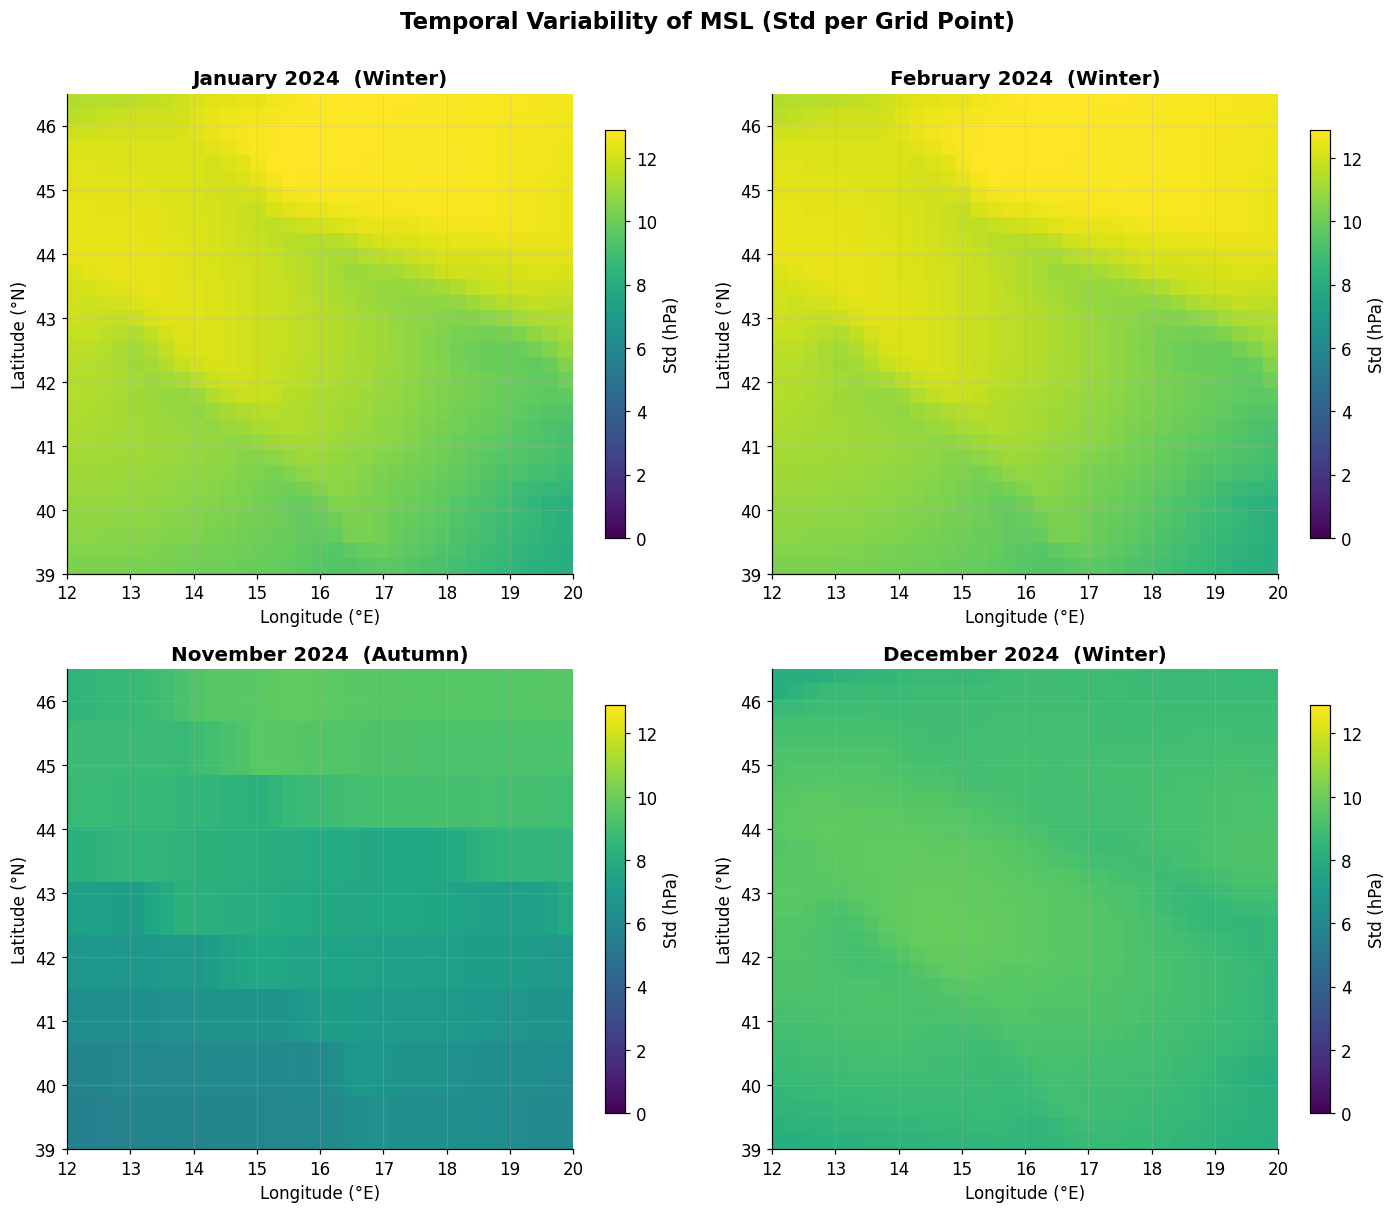

In [13]:
all_stds = [np.nanstd(d['samples'], axis=1) for d in data.values()]
smax = max(np.nanmax(s) for s in all_stds)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (month, d) in zip(axes, data.items()):
    point_std = np.nanstd(d['samples'], axis=1)
    grid, lons, lats = to_grid(point_std, d['lon'], d['lat'])

    im = ax.imshow(grid, cmap='viridis', vmin=0, vmax=smax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    ax.set_title(f'{month} 2024  ({d["season"]})')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label=f'Std ({UNIT})', shrink=0.85)

fig.suptitle(f'Temporal Variability of {VARIABLE} (Std per Grid Point)',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('msl_variability_maps.png', bbox_inches='tight')
plt.show()

## 8. Seasonal Aggregation — Winter vs Autumn

Pooling months by season to compare the overall pressure regime. January, February, and December represent Winter; November represents Autumn.

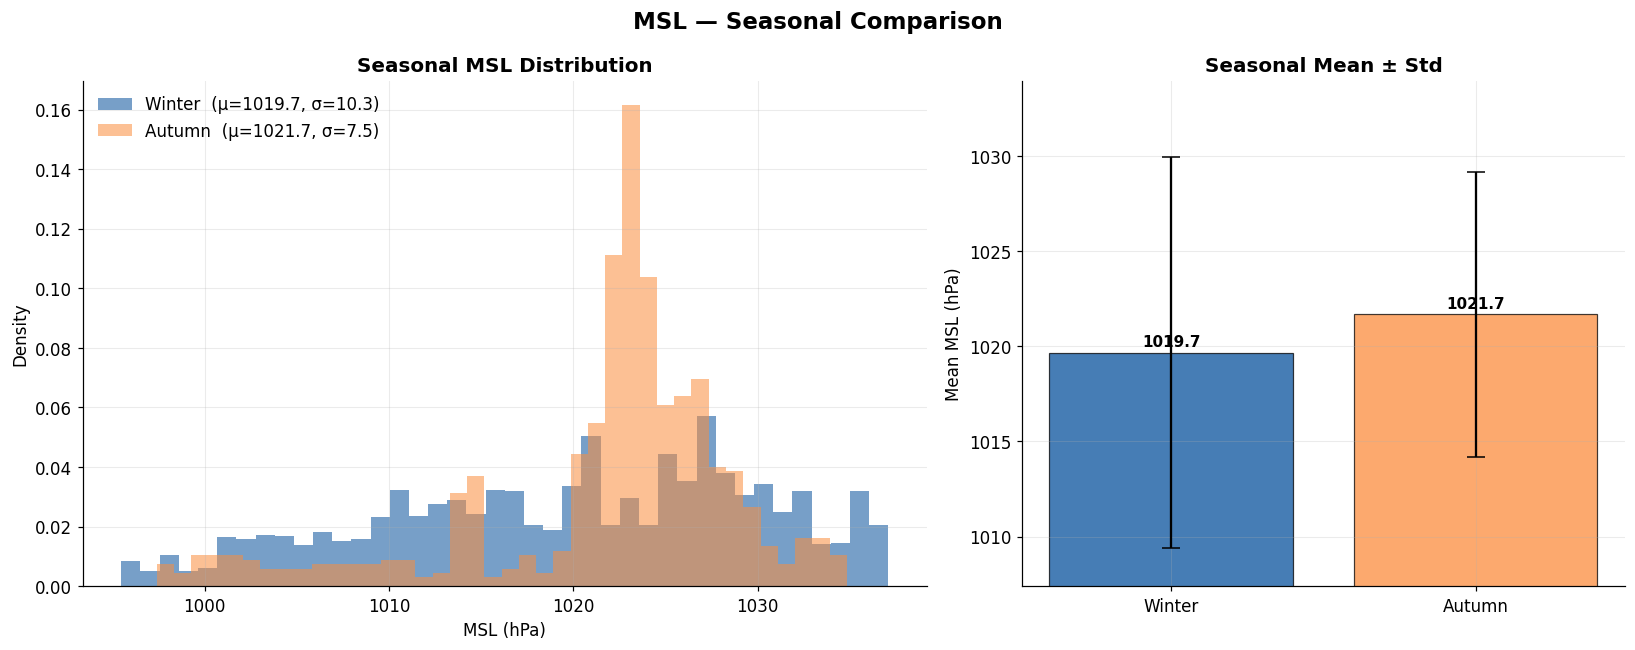

In [9]:
# Pool domain-mean time series by season
season_ts = {}
for month, d in data.items():
    s = d['season']
    ts = np.nanmean(d['samples'], axis=0)
    season_ts.setdefault(s, []).append(ts)

season_pooled = {s: np.concatenate(v) for s, v in season_ts.items()}

SEASON_COLORS = {'Winter': '#08519c', 'Autumn': '#fb8d3d',
                 'Spring': '#41ab5d', 'Summer': '#cb181d'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6),
                                gridspec_kw={'width_ratios': [1.4, 1]})

# ── Histogram overlay ───────────────────────────────────────────────────────
for s, pooled in season_pooled.items():
    ax1.hist(pooled, bins=40, alpha=0.55, density=True,
             color=SEASON_COLORS.get(s, 'gray'),
             label=f'{s}  (μ={pooled.mean():.1f}, σ={pooled.std():.1f})')
ax1.set_xlabel(f'{VARIABLE} ({UNIT})')
ax1.set_ylabel('Density')
ax1.set_title('Seasonal MSL Distribution')
ax1.legend()

# ── Bar chart: mean ± std ───────────────────────────────────────────────────
s_names = list(season_pooled.keys())
s_means = [season_pooled[s].mean() for s in s_names]
s_stds  = [season_pooled[s].std()  for s in s_names]
bars = ax2.bar(s_names, s_means, yerr=s_stds, capsize=6,
               color=[SEASON_COLORS.get(s, 'gray') for s in s_names],
               alpha=0.75, edgecolor='black', linewidth=0.8)
ax2.set_ylabel(f'Mean {VARIABLE} ({UNIT})')
ax2.set_title('Seasonal Mean ± Std')
ax2.set_ylim(min(s_means) - max(s_stds) - 2, max(s_means) + max(s_stds) + 2)
for bar, m in zip(bars, s_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle(f'{VARIABLE} — Seasonal Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('msl_seasonal_comparison.png', bbox_inches='tight')
plt.show()

## 9. Reference vs Samples — Bias Analysis

The `VALUE` column is the ERA5 reference field, while the `SAMPLE_*` columns are the realisations. Comparing them per grid point reveals the systematic bias between reference and samples, which can be stratified by month/season.

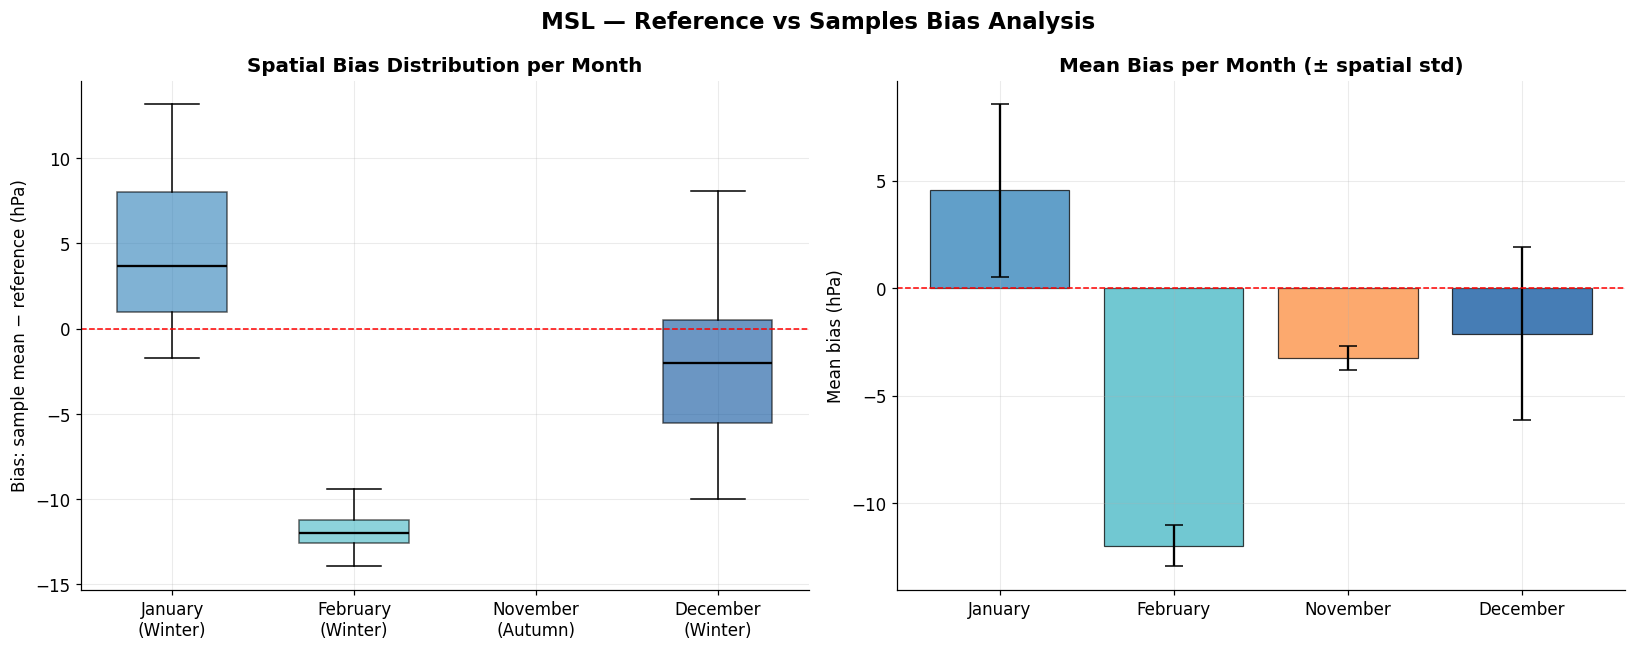


Bias summary (hPa):

          Season  Mean bias  Std bias
Month                                
January   Winter      4.546     4.027
February  Winter    -11.970     0.963
November  Autumn     -3.250     0.554
December  Winter     -2.111     4.012


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Bias per month (sample mean − reference) ────────────────────────────────
bias_rows = []
for month, d in data.items():
    sample_mean = np.nanmean(d['samples'], axis=1)   # per-point mean over time
    bias = sample_mean - d['value']                  # (n_points,)
    bias_rows.append({
        'Month'    : month,
        'Season'   : d['season'],
        'Mean bias': np.nanmean(bias),
        'Std bias' : np.nanstd(bias),
        'bias_arr' : bias,
    })

# Boxplot of spatial bias distribution per month
ax = axes[0]
bp = ax.boxplot([r['bias_arr'] for r in bias_rows], patch_artist=True,
                widths=0.6, medianprops=dict(color='black', linewidth=1.5))
for patch, r in zip(bp['boxes'], bias_rows):
    patch.set_facecolor(MONTH_COLORS[r['Month']]); patch.set_alpha(0.6)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xticks(range(1, len(bias_rows)+1))
ax.set_xticklabels([f'{r["Month"]}\n({r["Season"]})' for r in bias_rows])
ax.set_ylabel(f'Bias: sample mean − reference ({UNIT})')
ax.set_title('Spatial Bias Distribution per Month')

# ── Bias summary bar ────────────────────────────────────────────────────────
ax = axes[1]
mlabels = [r['Month'] for r in bias_rows]
mbias   = [r['Mean bias'] for r in bias_rows]
mstd    = [r['Std bias']  for r in bias_rows]
bars = ax.bar(mlabels, mbias, yerr=mstd, capsize=6,
              color=[MONTH_COLORS[m] for m in mlabels],
              alpha=0.75, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_ylabel(f'Mean bias ({UNIT})')
ax.set_title('Mean Bias per Month (± spatial std)')

fig.suptitle(f'{VARIABLE} — Reference vs Samples Bias Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('msl_bias_analysis.png', bbox_inches='tight')
plt.show()

# Print bias table
bias_df = pd.DataFrame([{k: r[k] for k in ['Month','Season','Mean bias','Std bias']}
                        for r in bias_rows]).set_index('Month').round(3)
print(f'\nBias summary ({UNIT}):\n')
print(bias_df.to_string())

## 10. Key Findings

Auto-generated summary of the seasonal analysis.

In [11]:
print('='*60)
print(f'  {VARIABLE} SEASONAL ANALYSIS — KEY FINDINGS')
print('='*60)

# Most/least variable month
var_by_month = {m: np.nanmean(d['samples'], axis=0).std() for m, d in data.items()}
most_var  = max(var_by_month, key=var_by_month.get)
least_var = min(var_by_month, key=var_by_month.get)

# Highest/lowest mean
mean_by_month = {m: np.nanmean(d['samples']) for m, d in data.items()}
high_m = max(mean_by_month, key=mean_by_month.get)
low_m  = min(mean_by_month, key=mean_by_month.get)

print(f'\n  Temporal variability (synoptic activity):')
print(f'    Most variable : {most_var}  (σ={var_by_month[most_var]:.2f} {UNIT})')
print(f'    Least variable: {least_var}  (σ={var_by_month[least_var]:.2f} {UNIT})')

print(f'\n  Mean pressure level:')
print(f'    Highest: {high_m}  ({mean_by_month[high_m]:.2f} {UNIT})')
print(f'    Lowest : {low_m}  ({mean_by_month[low_m]:.2f} {UNIT})')

print(f'\n  Seasonal means:')
for s, pooled in season_pooled.items():
    print(f'    {s:7s}: {pooled.mean():.2f} ± {pooled.std():.2f} {UNIT}')

print(f'\n  Generated figures:')
for f in ['msl_monthly_timeseries', 'msl_distributions', 'msl_diurnal_cycle',
          'msl_spatial_maps', 'msl_variability_maps', 'msl_seasonal_comparison',
          'msl_bias_analysis']:
    print(f'    - {f}.png')
print('='*60)

  MSL SEASONAL ANALYSIS — KEY FINDINGS

  Temporal variability (synoptic activity):
    Most variable : January  (σ=10.95 hPa)
    Least variable: November  (σ=7.47 hPa)

  Mean pressure level:
    Highest: November  (1021.68 hPa)
    Lowest : January  (1019.27 hPa)

  Seasonal means:
    Winter : 1019.67 ± 10.27 hPa
    Autumn : 1021.68 ± 7.47 hPa

  Generated figures:
    - msl_monthly_timeseries.png
    - msl_distributions.png
    - msl_diurnal_cycle.png
    - msl_spatial_maps.png
    - msl_variability_maps.png
    - msl_seasonal_comparison.png
    - msl_bias_analysis.png
